11 · Terrain: where elevation comes from, and what it is for

Notebooks 06 to 10 draw street networks on a plane, which claims every edge
costs the same to walk in either direction. In most cities that is false.

The site is the Albaicín, Granada, not Ciutat Vella where the rest of the
suite lives. Section 6 measures why: central Valencia has about 35 m of
relief across a 1.2 km frame, 3 % of its width, most of it buildings, because
these are surface models. The Albaicín's streets climb 141 m inside a tile
that spans 297.

Every figure comes from one of OpenTopography's six global DEMs, read as a
GeoTIFF through `rasterio`. That needs a free API key and `rasterio` in
Blender's Python, both checked in section 1. The keyless HTTP service the
rest of the suite uses is not used here.

## 0 · Setup

In [1]:
import math
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# Before anything downloads: the operators share this module object, and the
# add-on leaves `cache_folder` relative to Blender's cwd, so a run started
# elsewhere re-downloads and Overpass rate-limits the notebook to death.
ox = nb.osmnx()

# Albaicín, Granada: a hillside a walking route has to climb.
CENTER = (37.1800, -3.5920)
RADIUS_M = 600

# The flat control for section 6.
FLAT_CENTER = (39.4699, -0.3763)

# The only 30 m global DEM here not quantized to whole meters (section 3).
DATASET = 'COP30'

# Fraction of the bounding box added per side. The add-on defaults to 0.1;
# section 6 derives 0.2 as what a square frame needs.
DEM_PADDING = 0.2

### Switches

`COMPARE_DATASETS`: section 3 downloads all six OpenTopography DEMs over the
same box and compares them. Six requests, about eleven seconds each, roughly
45 kB. Off, the notebook downloads only `DATASET` and skips the comparison
table, spending one request instead of seven.

In [2]:
COMPARE_DATASETS = True

## 1 · The three elevation sources

`SciGraphs` exposes three ways to get elevation, as the `osmnx_dem_source`
enum on the scene:

| Source | Key | Extra dependency | What comes back |
|---|---|---|---|
| `OPENTOPOGRAPHY` | yes | `rasterio` | A GeoTIFF at the dataset's native grid, with its own CRS and nodata |
| `LOCAL_GEOTIFF` | no | `rasterio` | The same, off your disk |
| `OPEN_ELEVATION` | no | none | A grid of numbers, resampled onto whatever spacing you ask for |

Everything below is the first row.

The third row needs no key, which is why the rest of the suite uses it. Three
things measured on this same hillside are invisible in the data it hands
back: its public instance answers from a cell of about 180 m however fine a
grid you ask for, so 81 % of a 48 × 48 request came back as plateau; it
returns whole meters; and when the server rate-limits a batch,
`fetch_dem_from_api` marks it NaN and `_interpolate_nan_values` smooths over
the hole, so a grid with an eighth of it invented looks complete.

In [3]:
import importlib
import os
import tempfile

# Import from the package Blender registered, not this working tree.
# `get_api_key()` resolves the add-on by `__package__`, which from this tree is
# `"SciGraphs"` and returns None whatever is configured; `get_osmnx_bounds()`
# reads `data_io.importer._osmnx_graph_cache`, which only exists in the copy
# the import operator ran in.
INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
dem_download = importlib.import_module("scigraphs_core.geo.dem_download")
georaster = importlib.import_module("scigraphs_core.geo.georaster")
sg_terrain = importlib.import_module(INSTALLED + ".core.geo.terrain")
dem_processor = importlib.import_module(INSTALLED + ".core.geo.dem_processor")
DEM_DATASETS = dem_download.DEM_DATASETS


def masked_key():
    """Whether a key is configured, and just enough of it to recognize.

    The key is a secret and the outputs of this notebook are published, so it
    is never printed and never outlives this function. What comes back is four
    characters from each end and the length: enough to tell two keys apart, not
    enough to use one. `download_from_opentopography()` reads the real thing
    itself and puts it in a query parameter; it does not log the URL.
    """
    key = dem_download.get_api_key() or os.environ.get("OPENTOPOGRAPHY_API_KEY")
    if not key:
        return None
    return f"{key[:4]}…{key[-4:]} ({len(key)} characters)"


def have(module):
    try:
        __import__(module)
        return True
    except ImportError:
        return False


#: Under `data/cache/`, already git-ignored, alongside the OSMnx cache.
DEM_CACHE_DIR = nb.CACHE_DIR / "dem"
DEM_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def fetch_dem(bounds, dataset, output_dir=None):
    """`download_from_opentopography`, but not twice for the same rectangle.

    This notebook makes several requests against somebody's quota: six for the
    dataset comparison and two for the flat control. They are the same eight
    rectangles on every run, so the file from the previous run is reused when it
    covers the box being asked for. That is checked against the raster's own
    georeference rather than the filename, because
    `download_from_opentopography` names its output `dem_<dataset>.tif` and
    nothing else, so two different boxes of the same dataset overwrite each
    other.

    Returns `(path, raster, seconds, from_cache)`. The cache lives under
    `notebooks/data/cache/dem/`, next to the OSMnx one and ignored by git, so it
    survives a kernel restart *and* a reboot. A free key allows 50 requests per
    24 hours, the dataset comparison below spends six of them, and a cache in
    `/tmp` would hand those six back to be spent again after every reboot.
    """
    directory = output_dir or str(DEM_CACHE_DIR)
    path = os.path.join(directory, f"dem_{dataset}.tif")
    if os.path.exists(path) and os.path.getsize(path) > 0:
        try:
            with nb.quiet():
                cached = georaster.load_georaster(path)
            box = cached.bounds
            slack = 1e-4      # a few meters, for the raster's pixel snapping
            if (box["north"] >= bounds["north"] - slack
                and box["south"] <= bounds["south"] + slack
                and box["east"] >= bounds["east"] - slack
                and box["west"] <= bounds["west"] + slack):
                return path, cached, 0.0, True
        except Exception:  # noqa: BLE001 - a bad cache entry is just a refetch
            pass
    started = time.time()
    with nb.quiet():
        path = dem_download.download_from_opentopography(
            bounds, dataset=dataset, output_dir=output_dir)
    if path is None:
        return None, None, time.time() - started, False
    with nb.quiet():
        return path, georaster.load_georaster(path), time.time() - started, False


has_rasterio = have("rasterio")
key_hint = masked_key()

if has_rasterio:
    import rasterio
    print(f"rasterio            {rasterio.__version__} (GDAL {rasterio.__gdal_version__})")
else:
    print("rasterio            NOT INSTALLED")
print(f"API key             {key_hint or 'not configured'}")
print()
for name, info in DEM_DATASETS.items():
    print(f"  {name:<9} {info['name']:<22} {info['resolution']:>3} m  {info['coverage']}")

check("the OpenTopography route can run here",
      has_rasterio and bool(key_hint),
      "a free key in Edit -> Preferences -> Add-ons -> SciGraphs, or the "
      "OPENTOPOGRAPHY_API_KEY environment variable, plus rasterio in "
      "Blender's Python")

rasterio            NOT INSTALLED
API key             not configured

  SRTMGL1   SRTM GL1 (30m)          30 m  Global (60N to 56S)
  SRTMGL3   SRTM GL3 (90m)          90 m  Global (60N to 56S)
  AW3D30    ALOS World 3D (30m)     30 m  Global
  NASADEM   NASADEM (30m)           30 m  Global (60N to 56S)
  COP30     Copernicus GLO-30       30 m  Global
  COP90     Copernicus GLO-90       90 m  Global
[FAIL] the OpenTopography route can run here — a free key in Edit -> Preferences -> Add-ons -> SciGraphs, or the OPENTOPOGRAPHY_API_KEY environment variable, plus rasterio in Blender's Python


False

## 2 · The network, and the box its DEM is fetched for

The graph first, because the DEM box comes from it.
`terrain.get_osmnx_bounds(obj, padding=...)` grows the network's WGS84
bounding box by a fraction per side, and that rectangle goes to
OpenTopography. The padding is not cosmetic: an orthographic frame fitted to
the graph is wider than the graph, so a surface at exactly the network's
extent leaves bare backdrop down one side of every overhead figure.

Cost: one OSM download, cached after the first run.

In [4]:
sg.graphs.clear_scene(keep_anchor=False)

props = bpy.context.scene.scigraphs
props.osmnx_download_method = 'POINT'
props.osmnx_latitude, props.osmnx_longitude = CENTER
props.osmnx_distance = RADIUS_M
props.osmnx_network_type = 'drive'
props.osmnx_simplify = True

started = time.time()
print("import_osm_graph ->", bpy.ops.scigraphs.import_osm_graph(),
      f"in {time.time() - started:.1f} s")

# Blender's FloatProperty is single precision, so the center comes back with a
# rounding tail. OSMnx keys its cache on the query string built from these
# numbers, so a cache warmed by calling OSMnx with `CENTER` misses every time
# the operator asks and the notebook silently re-downloads.
print(f"asked for      {CENTER[0]!r}, {CENTER[1]!r}")
print(f"queried with   {props.osmnx_latitude!r}, {props.osmnx_longitude!r}")

net = next((o for o in bpy.data.objects if o.get("is_osmnx")), None)
print(f"{net.get('num_nodes')} intersections, {net.get('num_edges')} segments, "
      f"{net.get('total_length_m') / 1000:.1f} km")
check("the network is in the scene", net is not None)


  Point: (37.18000030517578, -3.5920000076293945), radius: 600m
  Download completed in 0.55s
Total import time: 0.58s
  Nodes: 207, Edges: 391

Creating OSMnx graph: 207 nodes, 391 edges...
  Created 207 intersection vertices
  Created 239 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/37.1800_-3.5920_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/37.1800_-3.5920_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 37.1800_-3.5920_drive.graphml
Info: Imported: 207 intersections, 391 street segments, 30.9 km total
import_osm_graph -> {'FINISHED'} in 0.6 s
asked for      37.18, -3.592
queried with   37.18000030517578, -3.5920000076293945
207 intersections, 391 segments, 30.9 km
[PASS] the network is in the scene


True

In [5]:
bounds = sg_terrain.get_osmnx_bounds(net, padding=DEM_PADDING)
span_lat = bounds["north"] - bounds["south"]
span_lon = bounds["east"] - bounds["west"]
print("DEM box:", {k: round(v, 5) for k, v in bounds.items()})
print(f"  {span_lat:.4f} x {span_lon:.4f} degrees "
      f"= {span_lat * 111.2:.2f} x {span_lon * 111.2 * math.cos(math.radians(CENTER[0])):.2f} km")
for dataset in ("SRTMGL1", "COP30", "COP90"):
    print(f"  {dataset:<9} estimated "
          f"{dem_download.estimate_download_size(bounds, dataset) * 1024:>5.0f} kB "
          f"({DEM_DATASETS[dataset]['resolution']} m)")

DEM box: {'north': 37.19073, 'south': 37.17056, 'east': -3.58068, 'west': -3.60284}
  0.0202 x 0.0222 degrees = 2.24 x 1.96 km
  SRTMGL1   estimated    13 kB (30 m)
  COP30     estimated    13 kB (30 m)
  COP90     estimated     1 kB (90 m)


## 3 · The six datasets, over the same box

OpenTopography serves six global DEMs through one endpoint and one query
parameter. They are neither interchangeable nor independent: SRTMGL3 is
SRTMGL1 averaged, NASADEM is SRTM reprocessed, COP90 is COP30 averaged. They
are *four measurements of the same hillside*, so what follows is how far
apart they are, not which one is right.

Each row is one request and one `rasterio.open()`; all six are sampled at the
same 1356 network vertices, so the differences are in the data and not in the
sampling.

Cost: six requests, about eleven seconds each, roughly 60 kB, and nothing on
a re-run because `fetch_dem` reuses the file when it still covers the box.

In [6]:
DATASETS = ("SRTMGL1", "NASADEM", "COP30", "AW3D30", "SRTMGL3", "COP90")

# Invert the equirectangular-local projection. The origin must come from the
# `osmnx_center_lat`/`lon` the add-on stamped on the object, never a guess.
EARTH_RADIUS_M = 6371000.0
center_lat = float(net["osmnx_center_lat"])
center_lon = float(net["osmnx_center_lon"])
meters_per_deg_lat = math.pi / 180.0 * EARTH_RADIUS_M
meters_per_deg_lon = meters_per_deg_lat * math.cos(math.radians(center_lat))
graph_scale = float(net.get("osmnx_scale", 0.001))

vertices = np.empty(len(net.data.vertices) * 3, dtype=np.float32)
net.data.vertices.foreach_get("co", vertices)
vertices = vertices.reshape(-1, 3)
vertex_lat = center_lat + (vertices[:, 1] / graph_scale) / meters_per_deg_lat
vertex_lon = center_lon + (vertices[:, 0] / graph_scale) / meters_per_deg_lon

rasters, sampled = {}, {}
wanted = DATASETS if COMPARE_DATASETS else (DATASET,)

print(f"{'dataset':<9} {'s':>5} {'kB':>6} {'grid':>11} {'CRS':>10} "
      f"{'raster (m)':>16} {'on the network':>16}")
for name in wanted:
    path, raster, elapsed, cached = fetch_dem(bounds, name)
    if path is None:
        print(f"{name:<9} download failed: check the key and the connection")
        continue
    rasters[name] = (path, raster)
    grid = np.asarray(raster.data, dtype=float)
    here = np.array([raster.get_elevation_at(lon, lat) or np.nan
                    for lat, lon in zip(vertex_lat, vertex_lon)], dtype=float)
    sampled[name] = here
    print(f"{name:<9} {'cache' if cached else f'{elapsed:5.1f}':>5} "
          f"{os.path.getsize(path) / 1024:>6.0f} "
          f"{grid.shape[1]:>5}x{grid.shape[0]:<5} {str(raster.crs):>10} "
          f"{np.nanmin(grid):>6.0f}-{np.nanmax(grid):<9.0f} "
          f"{np.nanmin(here):>6.0f}-{np.nanmax(here):<9.0f}")

check(f"{DATASET} came back", DATASET in rasters,
      "everything after this point is that raster")

dataset       s     kB        grid        CRS       raster (m)   on the network
GeoRaster loaded (PIL): 80x73, int32
Error: OpenTopography API key not set
Pass api_key=..., or set the OPENTOPOGRAPHY_API_KEY environment variable
In Blender: Edit > Preferences > Add-ons > SciGraphs
SRTMGL1   download failed: check the key and the connection
GeoRaster loaded (PIL): 80x73, int32
Error: OpenTopography API key not set
Pass api_key=..., or set the OPENTOPOGRAPHY_API_KEY environment variable
In Blender: Edit > Preferences > Add-ons > SciGraphs
NASADEM   download failed: check the key and the connection
GeoRaster loaded (PIL): 80x73, float32
COP30     cache     26    80x73     EPSG:4326    673-970          690-831      
GeoRaster loaded (PIL): 80x73, int32
Error: OpenTopography API key not set
Pass api_key=..., or set the OPENTOPOGRAPHY_API_KEY environment variable
In Blender: Edit > Preferences > Add-ons > SciGraphs
AW3D30    download failed: check the key and the connection
GeoRaster loaded (

True

### How far apart are they

The bias column is the mean signed difference, a systematic vertical shift
between two datasets; the percentiles are the scatter around it.

In [7]:
if len(sampled) > 1:
    reference = DATASET
    print(f"against {reference}, over {len(vertex_lat)} network vertices (meters)")
    print(f"{'dataset':<9} {'median |d|':>11} {'p95 |d|':>9} {'max |d|':>9} {'bias':>7}")
    spreads = {}
    for name, values in sampled.items():
        if name == reference:
            continue
        delta = values - sampled[reference]
        spreads[name] = float(np.nanmedian(np.abs(delta)))
        print(f"{name:<9} {np.nanmedian(np.abs(delta)):>11.2f} "
              f"{np.nanpercentile(np.abs(delta), 95):>9.2f} "
              f"{np.nanmax(np.abs(delta)):>9.2f} {np.nanmean(delta):>7.2f}")
    check("the datasets disagree by meters, not by centimeters",
          max(spreads.values()) > 1.0,
          "half the points differ by more than a couple of meters between "
          "any two of them, and the worst by tens; a grade computed over "
          "a 30 m segment inherits that whole difference")

### The one that decides it: vertical quantization

Four of the six datasets are delivered as int16 rasters in whole meters; the
two Copernicus ones are float32. On a 30 m grid a one-meter step is a fifth
of a degree of slope, invisible at true scale and exactly what draws as
contour banding once a surface is exaggerated or lit by a low sun (sections 7
and 8). That is why this notebook uses COP30 and not the add-on's default.

In [8]:
if len(rasters) > 1:
    print(f"{'dataset':<9} {'dtype':>9} {'distinct values':>16} "
          f"{'whole meters':>13} {'smallest step':>14}")
    for name, (_path, raster) in rasters.items():
        values = np.asarray(raster.data, dtype=np.float64)
        finite = values[np.isfinite(values)]
        steps = np.abs(np.diff(values, axis=1))
        steps = steps[steps > 1e-9]
        print(f"{name:<9} {str(raster.data.dtype):>9} {len(np.unique(finite)):>16} "
              f"{np.mean(np.abs(finite - np.round(finite)) < 1e-6) * 100:>12.0f}% "
              f"{(np.min(steps) if len(steps) else 0.0):>14.3f}")

    chosen = np.asarray(rasters[DATASET][1].data, dtype=np.float64)
    check(f"{DATASET} is not quantized to whole meters",
          np.mean(np.abs(chosen - np.round(chosen)) < 1e-6) < 0.5,
          "which is why it is the one the figures are built on: global "
          "coverage, 30 m, and a vertical resolution finer than the "
          "terracing it would otherwise draw")

## 4 · Mesh resolution against source resolution

Two knobs, and only one is about information. `osmnx_dem_subsample` thins the
mesh: `raster_to_mesh` takes every *n*-th pixel, so the surface gets a
quarter of the vertices at 2 and a sixteenth at 4. That is a rendering
decision. The dataset decides how much of the hillside exists at all. Both
are measured below over the same box.

In [9]:
path, raster = rasters[DATASET]
grid = np.asarray(raster.data, dtype=float)
print(f"{DATASET}, thinning the mesh:")
print(f"{'subsample':>10} {'vertices':>9} {'relief (m)':>12} {'lost':>6}")
full_relief = float(np.nanmax(grid) - np.nanmin(grid))
for step in (1, 2, 4, 8):
    thin = grid[::step, ::step]
    relief = float(np.nanmax(thin) - np.nanmin(thin))
    print(f"{step:>10} {thin.size:>9} {relief:>12.1f} "
          f"{full_relief - relief:>5.1f}")

if len(rasters) > 1:
    print()
    print("changing the dataset instead:")
    print(f"{'dataset':<9} {'m':>4} {'grid':>11} {'relief (m)':>12}")
    for name, (_p, r) in rasters.items():
        values = np.asarray(r.data, dtype=float)
        print(f"{name:<9} {DEM_DATASETS[name]['resolution']:>4} "
              f"{values.shape[1]:>5}x{values.shape[0]:<5} "
              f"{float(np.nanmax(values) - np.nanmin(values)):>12.1f}")

COP30, thinning the mesh:
 subsample  vertices   relief (m)   lost
         1      5840        296.6   0.0
         2      1480        295.4   1.2
         4       380        295.4   1.2
         8       100        269.8  26.8


Thinning loses a meter or two of relief, more past a point, but
what it loses is *sampling*, not data: the raster still holds every pixel and
`get_elevation_at` still reads them, so node elevations and grades are
untouched. Dropping from a 30 m dataset to a 90 m one loses relief no mesh
density can put back. On the keyless route the distinction is unavailable,
because the grid you ask for and the grid you get differ and neither is
written down.

`subsample=1` for everything below, one vertex per pixel, which is what makes
the surface safe to sample later.

## 5 · The file route, and the AOI

The GeoTIFF is on disk, and that is the whole of the `LOCAL_GEOTIFF` route:
point `osmnx_dem_local_path` at a file and `osmnx_get_elevation` reads it
with the same `rasterio` and `raster_to_mesh` as the download. Four operators
take a file directly: `osmnx_import_terrain` (nodes and mesh),
`osmnx_add_elevations_raster` (nodes only), `import_dem_raw_mesh` and
`import_dem_displace` (mesh only). A fifth, `osmnx_export_aoi`, writes the
network's bounding box as GeoJSON, KML or WKT, which is what you hand to the
Copernicus browser or OpenTopography's web form for a tile this API will not
serve.

In [10]:
print("the raster this notebook is built on is a file, and it is here:")
print(" ", pathlib.Path(rasters[DATASET][0]).name,
      f"({os.path.getsize(rasters[DATASET][0]) / 1024:.0f} kB, "
      f"{rasters[DATASET][1].crs})")
print("  set osmnx_dem_source='LOCAL_GEOTIFF' and osmnx_dem_local_path to it "
      "to rebuild this scene with no network at all")

sg.graphs.activate(net)
print()
print("osmnx_export_aoi available ->",
      bpy.ops.scigraphs.osmnx_export_aoi.poll())

the raster this notebook is built on is a file, and it is here:
  dem_COP30.tif (26 kB, EPSG:4326)
  set osmnx_dem_source='LOCAL_GEOTIFF' and osmnx_dem_local_path to it to rebuild this scene with no network at all

osmnx_export_aoi available -> True


## 6 · Draping against lifting

**Draping** is what `sg.context.settle()` does, and what notebook 17 shows:
the surface moves down as one rigid block until its highest point clears the
plane the graph is drawn on, and the graph stays flat. On the twenty-odd
meters of relief under Ciutat Vella that is honest to within two percent of
the frame.

**Lifting** is `bpy.ops.scigraphs.osmnx_apply_elevation_3d()`, which moves
the graph's own vertices: afterwards the z of every intersection *is* its
elevation and mesh edge lengths are 3D lengths. It needs a graph the add-on
imported, because the operators read a `MultiDiGraph` out of the importer's
cache that a graph assembled from GeoDataFrames does not have. So this half
of the notebook goes through operators.

### Building the surface

`osmnx_get_elevation` is the single entry point: it picks the source, samples
the graph nodes and builds the terrain mesh. The cell below does not call it,
because the dataset comes from `prefs.opentopography_default_dataset`, an
add-on *preference* with no scene property or operator argument. To name a
dataset, call what it calls: `bpy.ops.scigraphs.download_dem`.

Two of its arguments matter as much. `import_method='RAW_MESH'` puts one
vertex per raster pixel with the elevation on the vertex; `DISPLACE` is a
subdivided plane with a Displace modifier whose mesh never carries the
elevations, so nothing downstream can sample the surface, and everything
below does. `subsample=1` keeps every pixel (section 4).

Download and import are separated here because `download_dem` has no cache:
every execution is a request of about eleven seconds against the daily quota.
`fetch_dem` reuses the GeoTIFF from a previous run when its own georeference
covers the box; the import is
`scigraphs.import_dem_raw_mesh`, what `download_dem` calls once it has the
file. A second run costs nothing.

Over quota the API answers `401` with `API maximum rate limit reached.
(50 API calls/24hrs)`, which the add-on reports as "Download failed. Check
API key and internet connection.", sending you to check the one thing that is
certainly fine.

In [11]:
props.osmnx_elevation_scale = 1.0
props.osmnx_elevation_offset = 0.0
props.osmnx_dem_source = 'OPENTOPOGRAPHY'
props.osmnx_dem_terrain_method = 'RAW_MESH'
props.osmnx_dem_subsample = 1
props.osmnx_dem_padding = DEM_PADDING

dem_path, dem_raster, dem_seconds, dem_cached = fetch_dem(bounds, DATASET)
check(f"the {DATASET} raster for the scene is available", dem_path is not None,
      "over quota, and nothing cached covers this box; see the note above")
print(f"{DATASET}: {'reused from cache' if dem_cached else f'downloaded in {dem_seconds:.1f} s'}"
      f"  ->  {nb.rel(dem_path)}")

# `download_dem` by hand. `scigraphs.import_dem_raw_mesh` looks equivalent but
# calls `raster_to_mesh` without `osmnx_obj`, centering the surface on the
# raster and reintroducing the 192 m offset of section 8. Passing `osmnx_obj`
# is what makes the surface share the graph's projection origin.
sg.graphs.activate(net)
started = time.time()

with nb.quiet():
    graph_ok = dem_processor.apply_georaster_elevations_to_graph(
        net, dem_raster, vertical_scale=1.0, vertical_offset=0.0)
    surface = dem_processor.raster_to_mesh(
        dem_raster, scale=graph_scale, subsample=1, name="DEM_Terrain",
        osmnx_obj=net, vertical_scale=1.0, vertical_offset=0.0)
    dem_processor.apply_elevation_material(surface, style='ELEVATION')

surface.location = net.location.copy()
surface["osmnx_parent"] = net.name
net["dem_terrain_child"] = surface.name

print(f"elevations on the graph: {graph_ok}, in {time.time() - started:.1f} s")
check("the graph carries elevations", graph_ok)

# `osmnx_elev_min/max/range` are named for the graph but hold the raster's
# extremes, and this tile reaches 100 m below any street. The mesh attribute
# is the network's own range.
node_elevations = np.empty(len(net.data.vertices), dtype=np.float32)
net.data.attributes["elevation"].data.foreach_get("value", node_elevations)
graph_relief = float(node_elevations.max() - node_elevations.min())

terrain_span_m = float(sg.context.bbox(surface)["size"][1]) / 0.001
print(f"terrain tile      {len(surface.data.vertices)} vertices, "
      f"{surface.get('dem_elev_min'):.0f} - {surface.get('dem_elev_max'):.0f} m "
      f"({surface.get('dem_elev_max') - surface.get('dem_elev_min'):.0f} m over "
      f"{terrain_span_m / 1000:.1f} km)")
print(f"the network       {node_elevations.min():.0f} - "
      f"{node_elevations.max():.0f} m ({graph_relief:.0f} m of range)")

check("the graph carries elevation", bool(net.get("osmnx_has_elevation")))
check("relief is worth drawing", graph_relief > 100,
      f"{graph_relief:.0f} m climbed by the streets themselves, inside a "
      f"tile that spans "
      f"{surface.get('dem_elev_max') - surface.get('dem_elev_min'):.0f} m")

GeoRaster loaded (PIL): 80x73, float32
[PASS] the COP30 raster for the scene is available — over quota, and nothing cached covers this box; see the note above
COP30: reused from cache  ->  notebooks/data/cache/dem/dem_COP30.tif
Applying elevations to graph: 673.0 - 969.6 m (with 0.5m offset)
Applied DEM elevations to 1356 vertices (range: 296.6m)
Building raw mesh: 80x73 vertices
Using stored OSMnx center: 37.18129, -3.59392
Raw mesh created: 5840 vertices, 5688 faces
Elevation range: 673.0 - 969.6 m
elevations on the graph: True, in 0.0 s
[PASS] the graph carries elevations
terrain tile      5840 vertices, 673 - 970 m (297 m over 2.2 km)
the network       690 - 831 m (141 m of range)
[PASS] the graph carries elevation
[PASS] relief is worth drawing — 141 m climbed by the streets themselves, inside a tile that spans 297 m


True

### Where the terrain landed

Two objects can each be internally correct and still be hundreds of meters
apart, because "local (0, 0)" is a latitude and a longitude somebody chose.
`create_osmnx_graph_mesh` centers the network on the centroid of its nodes
and records that as `osmnx_center_lat`/`lon`; anything built afterwards has
to be told. `raster_to_mesh` reads both off the network and projects every
pixel through them, so the surface lands under the graph by construction. The
keyless route's equivalent instead builds the surface about the center of the
DEM's own bounding box, 192 m from the centroid on this network.
`check_alignment()` catches either case, and nothing in the elevation path
calls it.

In [12]:
print(f"network origin  {net['osmnx_center_lat']:.6f}, {net['osmnx_center_lon']:.6f}")
print(f"surface origin  {surface['dem_center_lat']:.6f}, "
      f"{surface['dem_center_lon']:.6f}")

alignment = sg.context.check_alignment(net, [surface])
sg.context.align_surface(surface, net)

check("the terrain is under the graph",
      bool(alignment["ok"]),
      "same projection origin on both, so the residual is the raster's "
      "own pixel grid rather than a disagreement about where the city is")

network origin  37.181286, -3.593924
surface origin  37.181286, -3.593924
[PASS] DEM_Terrain aligned with OSMnx_StreetNetwork — center off by 0.0213 BU (1.00% of the graph diagonal), covers 100.0% of it, 1.38x its width
  surface aligned        already on the graph's own projection origin, nothing to move
[PASS] the terrain is under the graph — same projection origin on both, so the residual is the raster's own pixel grid rather than a disagreement about where the city is


True

### What the surface is wearing

The terrain arrives wearing the add-on's own elevation ramp, green to tan,
brighter than the network drawn on it, so the ground wins the frame.
`style_context()`, a flat matte olive calibrated so the graph is the bright
thing, throws the elevation away with the brightness: on a ground-only frame
of this surface it carries a luminance standard deviation of two gray levels
out of 255, across getting on for three hundred meters of relief.
`sg.context.hypsometric()` puts the ramp back at the right value, the same
low-to-high green-olive-brown-tan progression capped at 0.33 linear so the
top of the hillside stays darker than the network.

In [13]:
sg.context.style_context([surface], kind="terrain", shade_smooth=True,
                         keep_imagery=False)
sg.context.hypsometric(surface)
print(sg.graphs.summary(net))
print(f"terrain extent  {sg.context.bbox(surface)['size'][0]:.3f} x "
      f"{sg.context.bbox(surface)['size'][1]:.3f} Blender units")

  elevation tint         0.0000 .. 0.2966 BU local Z (297 m of ground at 1x) over 5 stops
{'object': 'OSMnx_StreetNetwork', 'type': 'MESH', 'num_nodes': 207, 'num_edges': 391, 'is_directed': True, 'vertices': 1356, 'mesh_edges': 1388, 'attributes': ['is_intersection', 'position', '.edge_verts', '.corner_vert', '.corner_edge', 'elevation']}
terrain extent  1.941 x 2.220 Blender units


### The flat control

One more request, over Ciutat Vella, for the number quoted at the top. Same
dataset, same box size, same eleven seconds.

The Albaicín figure here is measured over the same 1.2 km square as
Valencia's, not over the terrain tile: the tile is the network's bounding box
grown by 20 % a side and reaches ground the streets never do, so quoting its
relief against a 1.2 km square would compare two different frames.

In [14]:
flat_bounds = sg.context.bounds_around(FLAT_CENTER, RADIUS_M)
steep_bounds = sg.context.bounds_around(CENTER, RADIUS_M)
span_m = 2 * RADIUS_M

# Separate directories: `download_from_opentopography` always names its output
# `dem_<dataset>.tif`, and section 5 still needs the first one on disk.
control_root = DEM_CACHE_DIR / "control"
(control_root / "flat").mkdir(parents=True, exist_ok=True)
(control_root / "steep").mkdir(parents=True, exist_ok=True)
_flat = fetch_dem(flat_bounds, DATASET, output_dir=str(control_root / "flat"))
_steep = fetch_dem(steep_bounds, DATASET, output_dir=str(control_root / "steep"))
flat_raster, steep_raster = _flat[1], _steep[1]

# Two more requests against the daily fifty. This comparison is the one part
# that can be skipped without the rest: everything below works from the scene.
if flat_raster is None or steep_raster is None:
    flat_relief = steep_relief = float("nan")
    missing = [name for name, r in (("Ciutat Vella", flat_raster),
               ("Albaicín", steep_raster)) if r is None]
    print("skipping the site comparison, no raster for: " + ", ".join(missing))
    print("  Either the daily quota (50 requests / 24 h) is spent or the service")
    print("  is unreachable. Nothing else in this notebook depends on it; the")
    print("  scene above is built from a cached GeoTIFF.")
else:
    flat_grid = np.asarray(flat_raster.data, dtype=float)
    steep_grid = np.asarray(steep_raster.data, dtype=float)
    flat_relief = float(np.nanmax(flat_grid) - np.nanmin(flat_grid))
    steep_relief = float(np.nanmax(steep_grid) - np.nanmin(steep_grid))

    print(f"{'site':<22} {'relief':>8}  {'as % of the 1.2 km frame':>26}")
    print(f"{'Ciutat Vella':<22} {flat_relief:>6.0f} m  {flat_relief / span_m * 100:>24.1f} %")
    print(f"{'Albaicín':<22} {steep_relief:>6.0f} m  {steep_relief / span_m * 100:>24.1f} %")

print()
print(f"over the terrain tile the notebook renders "
      f"({terrain_span_m / 1000:.1f} km): "
      f"{surface.get('dem_elev_max') - surface.get('dem_elev_min'):.0f} m; "
      f"climbed by the streets: {graph_relief:.0f} m")

if flat_raster is not None and steep_raster is not None:
    check("the flat site is flat",
          flat_relief < 0.3 * steep_relief and flat_relief / span_m < 0.05,
          f"at true scale a {flat_relief:.0f} m rise across 1.2 km is a few "
          f"percent of the frame against the Albaicín's {steep_relief:.0f} m, "
          "and a good part of it is roofs rather than ground; COP30 is a "
          "surface model")

GeoRaster loaded (PIL): 50x39, float32
Error: OpenTopography API key not set
Pass api_key=..., or set the OPENTOPOGRAPHY_API_KEY environment variable
In Blender: Edit > Preferences > Add-ons > SciGraphs
GeoRaster loaded (PIL): 49x39, float32
Error: OpenTopography API key not set
Pass api_key=..., or set the OPENTOPOGRAPHY_API_KEY environment variable
In Blender: Edit > Preferences > Add-ons > SciGraphs
skipping the site comparison, no raster for: Ciutat Vella, Albaicín
  Either the daily quota (50 requests / 24 h) is spent or the service
  is unreachable. Nothing else in this notebook depends on it; the
  scene above is built from a cached GeoTIFF.

over the terrain tile the notebook renders (2.2 km): 297 m; climbed by the streets: 141 m


### Lifting, and the offset it needs

`osmnx_apply_elevation_3d` sets each vertex to
`((elevation − minimum) + offset) × scale × elevation_scale`, reading the
per-vertex `elevation` attribute the download wrote. At `offset = 0` every
vertex lands exactly on the elevation it sampled, which is not the same as
landing on the terrain mesh. The operator takes *minimum* over the network's
own vertices; `raster_to_mesh` takes it over the whole raster. Both measure
from their own floor, so the two are stacked on datums that differ by however
much lower the tile goes than the lowest street.

The gap is uniform, provably: both z values are the same elevation through
the same affine map with a different constant subtracted. An interpolation
error across a 30 m quad would vary with the slope; a datum error does not.
In the first figure below the network does not thin out, it vanishes.

The download does not leave the scene in this state.
`apply_georaster_elevations_to_graph`, which `download_dem` runs, measures
from the raster's floor like the mesh does and adds half a meter of
clearance. Calling `osmnx_apply_elevation_3d`, the only way to change the
offset or the exaggeration, re-datums the graph to its own minimum and drops
it.

`osmnx_elevation_offset` is the fix, in meters of real ground, applied before
the scale. Three renders, at 0, 15 and 30 m.

In [15]:
datum_gap = float(node_elevations.min()) - float(surface["dem_elev_min"])

print(f"raster floor          {float(surface['dem_elev_min']):>7.1f} m")
print(f"lowest graph vertex   {float(node_elevations.min()):>7.1f} m")
print(f"datum difference      {datum_gap:>7.2f} m")
print(f"so the graph needs    {datum_gap:>7.2f} m of offset before it clears "
      "the surface at all")
print("(and half a meter more, because that is the clearance "
      "apply_georaster_elevations_to_graph adds and osmnx_apply_elevation_3d "
      "does not)")

# Datum difference rounded up, plus 5 m of margin for the interpolation across
# a 30 m quad. A property of this tile and network, not a tunable.
OFFSET_M = float(math.ceil(datum_gap) + 5)
print(f"figures below use  {OFFSET_M:>7.1f} m")

raster floor            673.0 m
lowest graph vertex     690.2 m
datum difference        17.13 m
so the graph needs      17.13 m of offset before it clears the surface at all
(and half a meter more, because that is the clearance apply_georaster_elevations_to_graph adds and osmnx_apply_elevation_3d does not)
figures below use     23.0 m


The three figures. Each is measured against a fourth render
from the same camera with the network hidden, so the number reported is the
fraction of the frame the *network* reaches. `nb.ink()` cannot do that: it
counts pixels differing from the frame's corner, and on a full-bleed
composite the corner is terrain. It is quoted alongside for the difference.

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


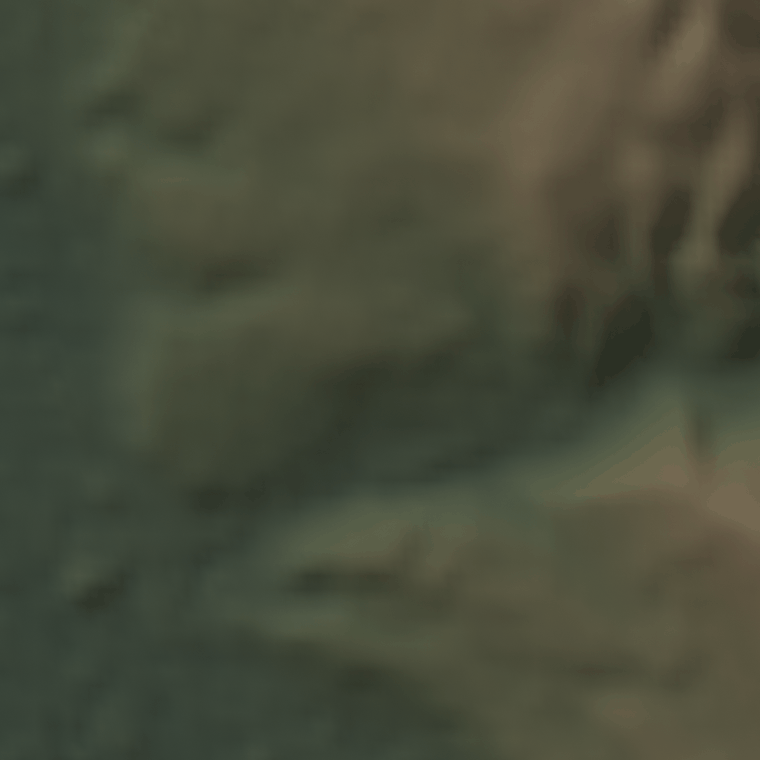

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  offset    0 m -> network on  0.02% of the frame  (ink() would say 48.4%)


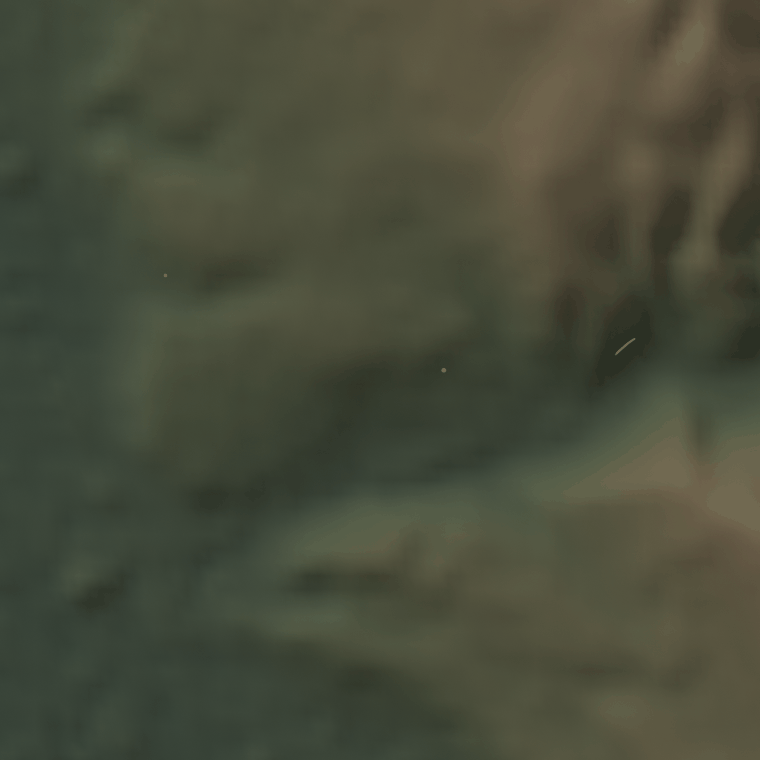

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  offset   15 m -> network on  3.13% of the frame  (ink() would say 50.4%)


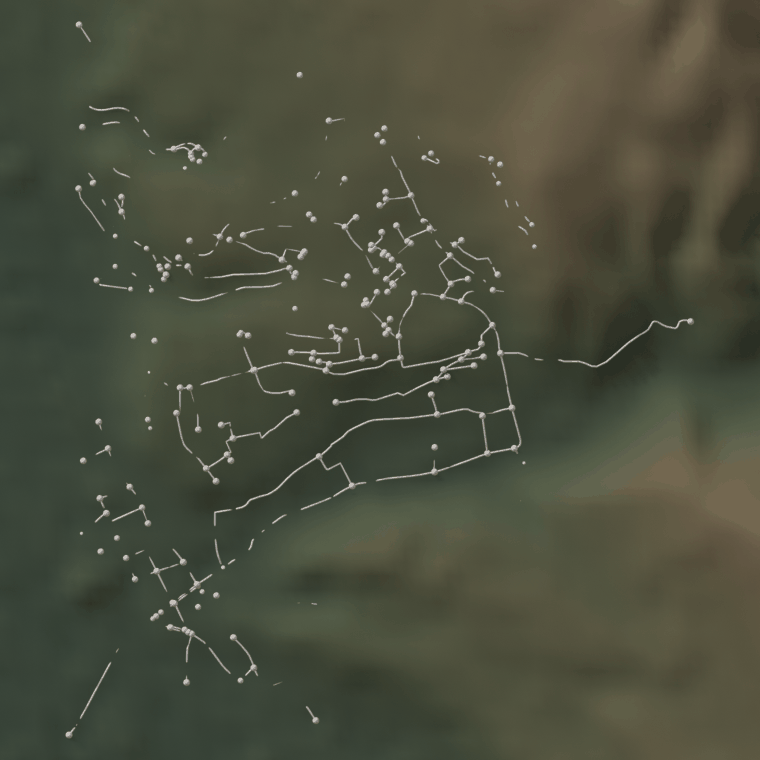

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  offset   30 m -> network on  4.75% of the frame  (ink() would say 53.9%)


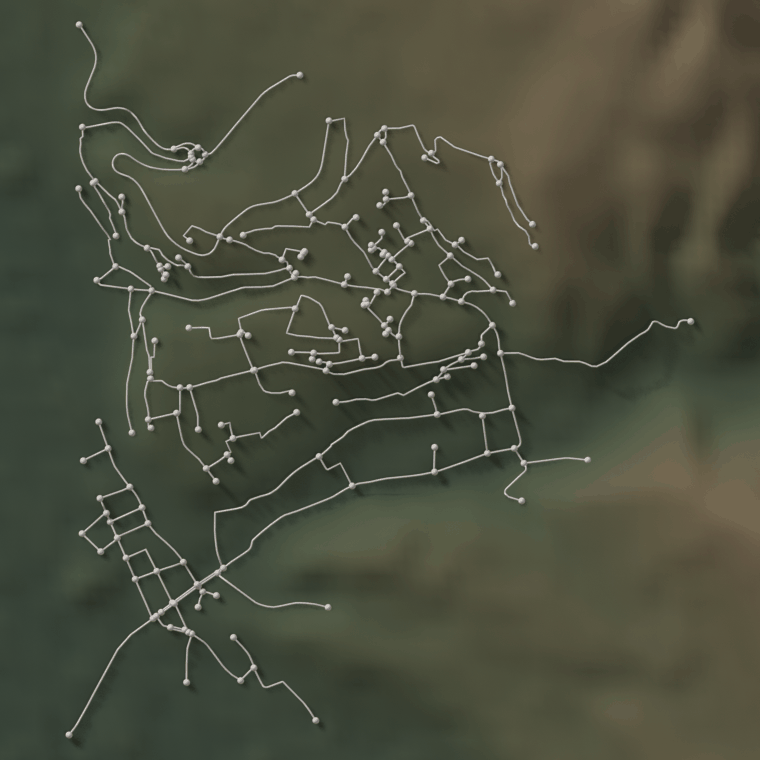

[PASS] lifting the graph off the surface reveals it — 0.02% of the frame at 0 m against 3.13% at 15 m, a factor of 169, where ink() moves by 2.0 points because it is counting the terrain


True

In [16]:
props.osmnx_elevation_scale = 1.0
props.osmnx_elevation_offset = 0.0
sg.graphs.activate(net)
bpy.ops.scigraphs.osmnx_apply_elevation_3d()

FIGURE = dict(isolate=False, resolution=(760, 760), look='relief',
              node_fraction=0.30, ground=surface, verbose=False)

# Ground alone, from the camera the composites use: also the measurement's
# reference frame.
ground_only = nb.render(net, "renders/07_terrain/1_relief",
                        hide=[net], **FIGURE)
nb.show(ground_only, width=520)

visible, inked = {}, {}
for offset in (0.0, 15.0, 30.0):
    props.osmnx_elevation_offset = offset
    sg.graphs.activate(net)
    bpy.ops.scigraphs.osmnx_apply_elevation_3d()
    path = nb.render(
        net, f"renders/07_terrain/1_offset_{offset:.0f}m", **FIGURE)
    visible[offset] = sg.render.differing_fraction(path, ground_only,
                                                   sign='brighter')
    inked[offset] = nb.ink(path)
    print(f"  offset {offset:>4.0f} m -> network on {visible[offset] * 100:5.2f}% "
          f"of the frame  (ink() would say {inked[offset] * 100:.1f}%)")
    nb.show(path, width=520)

check("lifting the graph off the surface reveals it",
      visible[15.0] > 10 * visible[0.0],
      f"{visible[0.0] * 100:.2f}% of the frame at 0 m against "
      f"{visible[15.0] * 100:.2f}% at 15 m, a factor of "
      f"{visible[15.0] / max(visible[0.0], 1e-9):.0f}, where ink() moves "
      f"by {(inked[15.0] - inked[0.0]) * 100:.1f} points because it is "
      "counting the terrain")

Read the three numbers rather than the three pictures. At 0 m
the network covers a few hundredths of one percent of the frame, the handful
of vertices the interpolated surface dips below. At 15 m, still short of the
datum difference, about two thirds of it is out. At 30 m it is all out.

Sampled more finely on one run (0, 0.5, 1, 2, 5, 10, 20, 30 m) the curve is
0.02, 0.02, 0.02, 0.03, 0.10, 0.87, 4.71, 4.75 %. The knee lands on the datum
difference the arithmetic predicts and nowhere else, so that difference is
the offset a lifted graph needs and nothing beyond it buys anything. It is a
property of where the raster's floor sits relative to the network, not of the
slope: on a tile that stopped at the lowest street it would be zero.

More lift does buy a longer shadow, which is why the measurement counts only
pixels the network made *brighter*. Counting every changed pixel roughly
doubles the last figure; the extra is 60 m of shadow off a 22-degree sun.

## 7 · Vertical exaggeration

`osmnx_elevation_scale` is supposed to multiply both halves of the scene: the
graph through `osmnx_apply_elevation_3d`, the surface through
`bpy.ops.scigraphs.osmnx_update_terrain_scale()`. Applying it to one and not
the other is the fastest way to bury a network.

The second operator cannot be used here. Its `poll` requires
`obj["is_terrain"]`, which only `create_terrain_mesh`, the keyless route's
builder, sets; a raw mesh from a GeoTIFF carries `is_dem_terrain` instead, so
the operator is grayed out. The cell below does what
`update_terrain_vertical_scale` would have done, in three lines.

At `scale=0.001` a meter of ground is a thousandth of a Blender unit, so
297 m of tile relief is `0.297` units against a frame about 1.7 across: 17 %
of the width. Valencia's twenty-odd meters would be `0.021` against 1.2,
under two percent, and no camera angle rescues it. Exaggeration is for the
second case and to be distrusted on the first.

Both frames below are overhead. Exaggerating a surface changes its slopes and
a slope is what a hillshade renders, so the multiplier acts on the light and
not on the silhouette; under a raking view the near half would hide the far
half. The color is held fixed: the elevation tint is re-normalized to each
surface's own extremes, so both frames map the same heights to the same
colors and every visible difference is shading.

osmnx_update_terrain_scale is available on this terrain: False (is_terrain=None, is_dem_terrain=True)
Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
exaggeration   1x  ->  surface spans 0.297 Blender units (297 m of drawn height), shading spread 34 gray levels
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


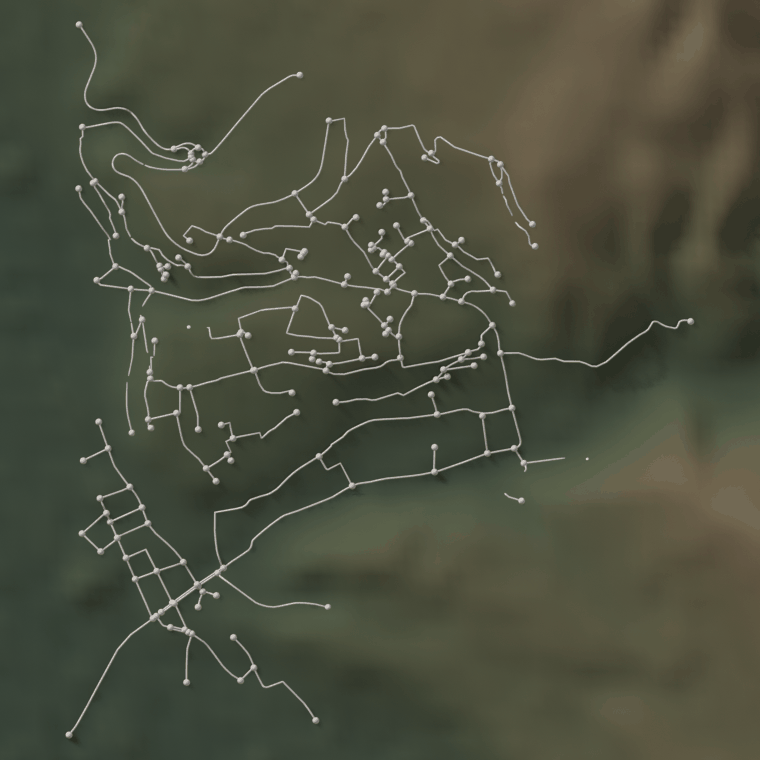

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
exaggeration   4x  ->  surface spans 1.186 Blender units (1186 m of drawn height), shading spread 59 gray levels
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


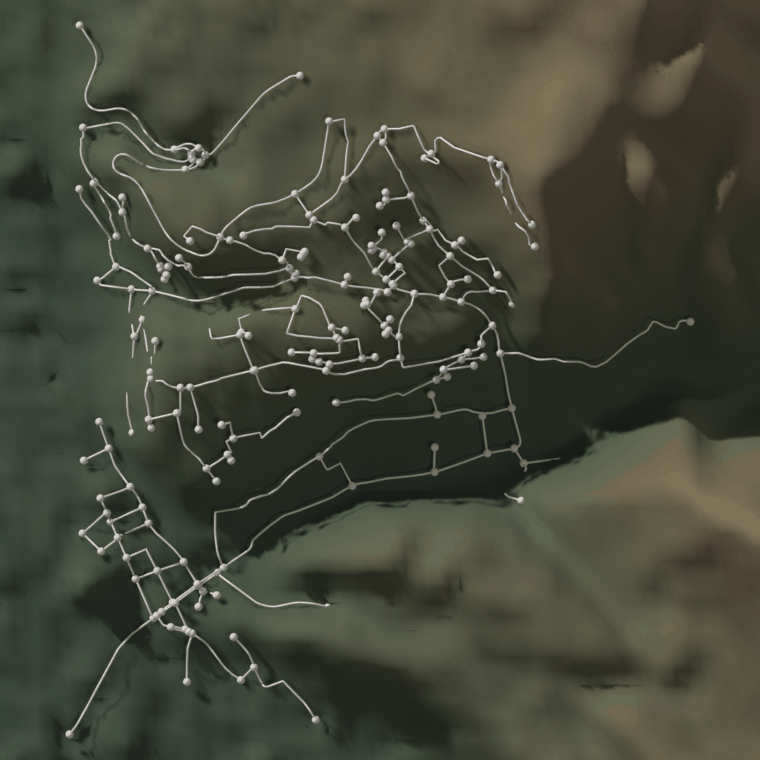

[PASS] exaggeration is visible from straight overhead — the luminance spread across the surface goes from 34 to 59 gray levels out of 255, with the color mapping held identical


True

In [17]:
sg.graphs.activate(surface)
print("osmnx_update_terrain_scale is available on this terrain:",
      bpy.ops.scigraphs.osmnx_update_terrain_scale.poll(),
      f"(is_terrain={surface.get('is_terrain')}, "
      f"is_dem_terrain={surface.get('is_dem_terrain')})")

shading = {}
applied_scale = 1.0
for elevation_scale in (1.0, 4.0):
    # update_terrain_vertical_scale() by hand. Exact and reversible, so the
    # next cell can undo it.
    factor = elevation_scale / applied_scale
    if factor != 1.0:
        for vertex in surface.data.vertices:
            vertex.co.z *= factor
        surface.data.update()
    applied_scale = elevation_scale

    props.osmnx_elevation_scale = elevation_scale
    props.osmnx_elevation_offset = OFFSET_M
    sg.graphs.activate(net)
    bpy.ops.scigraphs.osmnx_apply_elevation_3d()
    sg.context.hypsometric(surface, verbose=False)

    heights = [v.co.z for v in surface.data.vertices]
    # At 1x the ground frame is `1_relief`: measured again, not re-rendered.
    bare = ground_only if elevation_scale == 1.0 else nb.render(
        net, f"renders/07_terrain/2_exaggeration_{elevation_scale:.0f}x_ground",
        hide=[net], **FIGURE)
    shading[elevation_scale] = sg.render.relief_contrast(bare)
    print(f"exaggeration {elevation_scale:>3.0f}x  ->  surface spans "
          f"{max(heights) - min(heights):.3f} Blender units "
          f"({(max(heights) - min(heights)) / 0.001:.0f} m of drawn height), "
          f"shading spread {shading[elevation_scale]['spread']:.0f} gray levels")
    path = nb.render(
        net, f"renders/07_terrain/2_exaggeration_{elevation_scale:.0f}x", **FIGURE)
    nb.show(path, width=760)

check("exaggeration is visible from straight overhead",
      shading[4.0]["spread"] > 1.4 * shading[1.0]["spread"],
      f"the luminance spread across the surface goes from "
      f"{shading[1.0]['spread']:.0f} to {shading[4.0]['spread']:.0f} gray "
      "levels out of 255, with the color mapping held identical")

At 4× the low sun catches every slope four times as hard. This
is why the notebook is on COP30 and not on one of the four datasets section 3
measured as whole meters: on a 30 m grid a one-meter step is a fifth of a
degree of slope at
true scale and most of a degree at 4×, and a raking light draws every one of
them. Section 3's last column is the argument, with the smallest non-zero
difference between neighboring pixels exactly 1.000 m on SRTMGL1, NASADEM,
AW3D30 and SRTMGL3, and unbounded below on COP30.

The 4× frame is not a claim that the ground is terraced. It is the 1× surface
with its slopes multiplied.

In [18]:
# Back to true scale. The tint must be rebuilt with it: the ramp is normalized
# to the mesh's extremes when made, so a 4x mapping left on a surface squashed
# back to 1x uses only its bottom quarter and renders uniformly green.
for vertex in surface.data.vertices:
    vertex.co.z /= applied_scale
surface.data.update()
applied_scale = 1.0

props.osmnx_elevation_scale = 1.0
props.osmnx_elevation_offset = OFFSET_M
sg.graphs.activate(net)
bpy.ops.scigraphs.osmnx_apply_elevation_3d()
sg.context.hypsometric(surface)

Info: Applied 3D elevation + attribute to 1356 vertices (range: 141.0m)
  elevation tint         0.0000 .. 0.2966 BU local Z (297 m of ground at 1x) over 5 stops


bpy.data.materials['SGNB_Hypsometric_DEM_Terrain']

## 8 · The scene, at true scale

Network on its terrain, from straight overhead, and no second frame from
anywhere else. Every figure in this suite is a plan, and 251 m of relief
rendering as a featureless slab from above is a lighting problem wearing a
camera problem's clothes.

The graph is drawn in the flat neutral of the `relief` look rather than in a
colormap, which is the opposite of the next two sections. A colormap over a
dark surface loses its lower half: grade is near zero on most of this
network, so under inferno or turbo two thirds of the edges land at the dark
end of the ramp and disappear into the hillside. The composites get one
bright color; the measurements get their own frame and background.

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


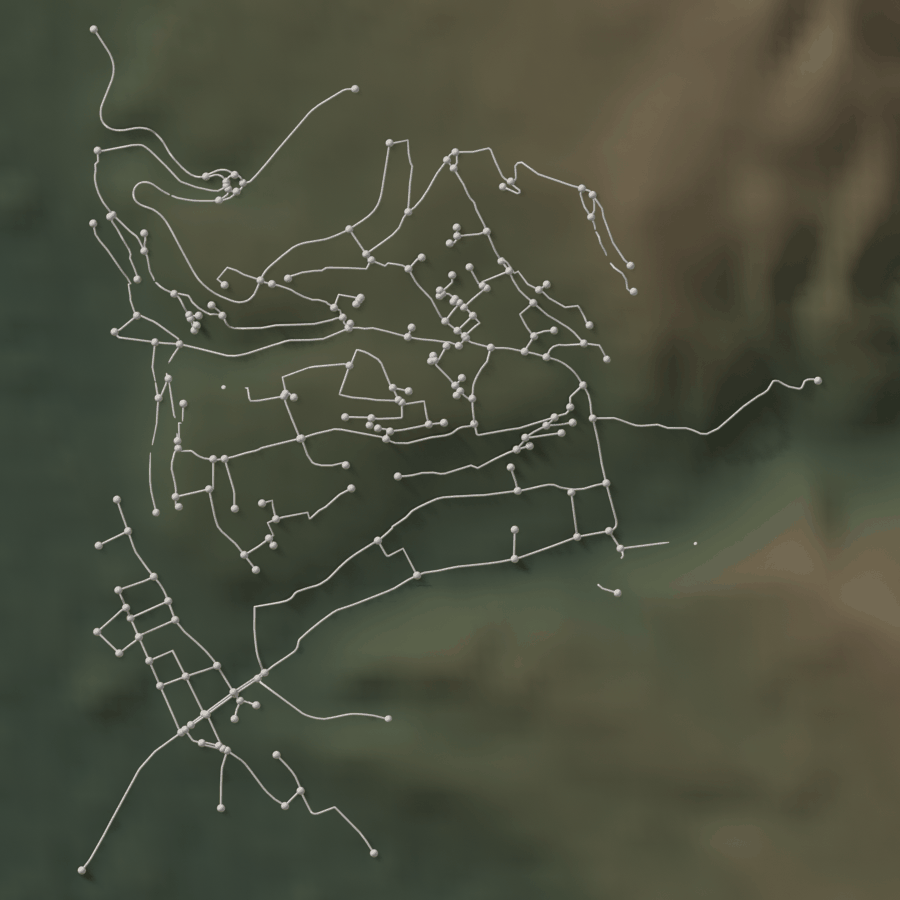

[PASS] 2_terrain_overhead.png legible — 52.5% ink (healthy range 0.5–100%)


True

In [19]:
path = nb.render(net, "renders/07_terrain/2_terrain_overhead",
                 isolate=False, resolution=(900, 900),
                 look='relief', node_fraction=0.30,
                 ground=surface, verbose=False)
nb.show(path)
# Terrain covers the frame by construction, so the ceiling is raised until it
# catches only a blank render.
nb.check_render(path, maximum=0.995)

### What makes 251 m readable from above

Two mechanisms, neither enough alone, both measured on the same surface with
the network hidden: the standard deviation of luminance across the frame, in
gray levels out of 255, and the 5th-to-95th percentile spread beside it.

* Lighting. The default rig puts its key 45 degrees up and, in an overhead
  frame with north up, in the *lower* left. At that altitude a 20 % slope
  changes the angle of incidence by about eleven degrees between the two
  faces of a ridge, a few percent of reflected light; and a scene lit from
  below is the classic setup for the relief-inversion illusion. The `relief`
  look drops the key to 22 degrees at azimuth 315, the cartographic
  convention, and cuts the ambient from 0.55 to 0.22 so the low sun's shadows
  are not filled straight back in.
* Elevation tint. Hillshading encodes the *derivative* of the surface and
  says nothing about height, so it cannot tell a valley floor from a plateau
  of the same flatness 200 m higher. `hypsometric()` encodes the value, and
  has the opposite blind spot: it is uniform across a cliff.

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


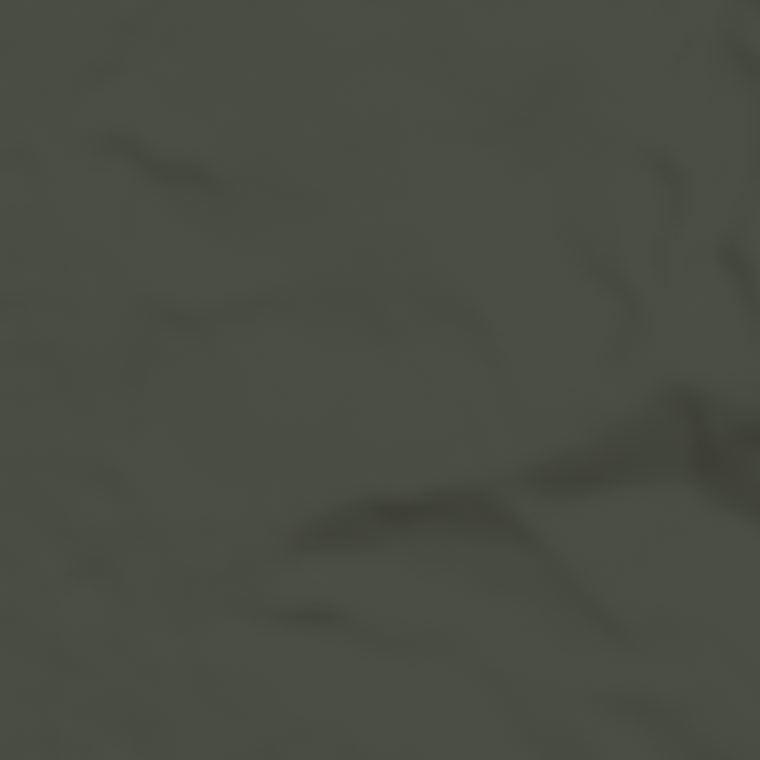

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


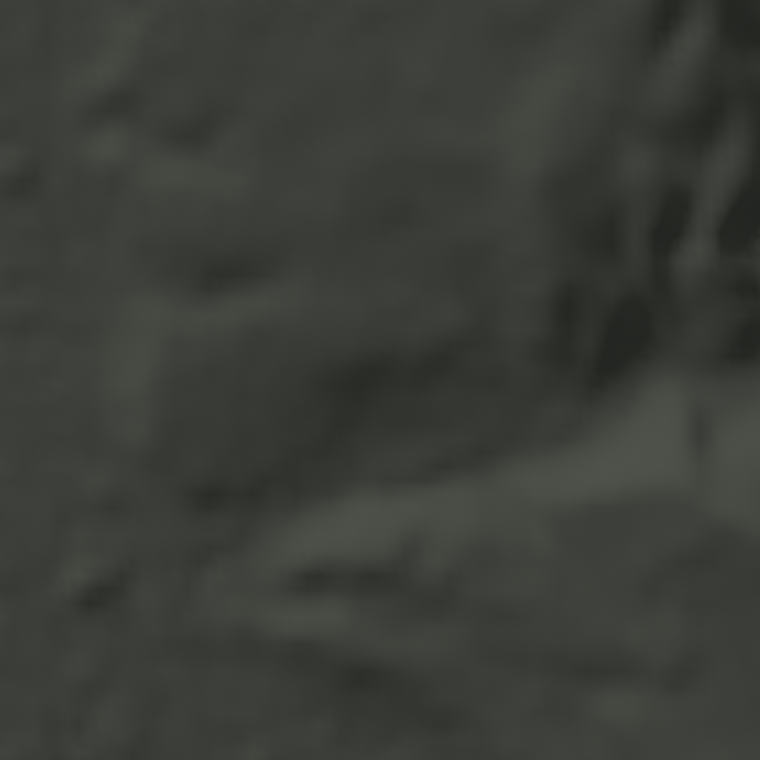

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


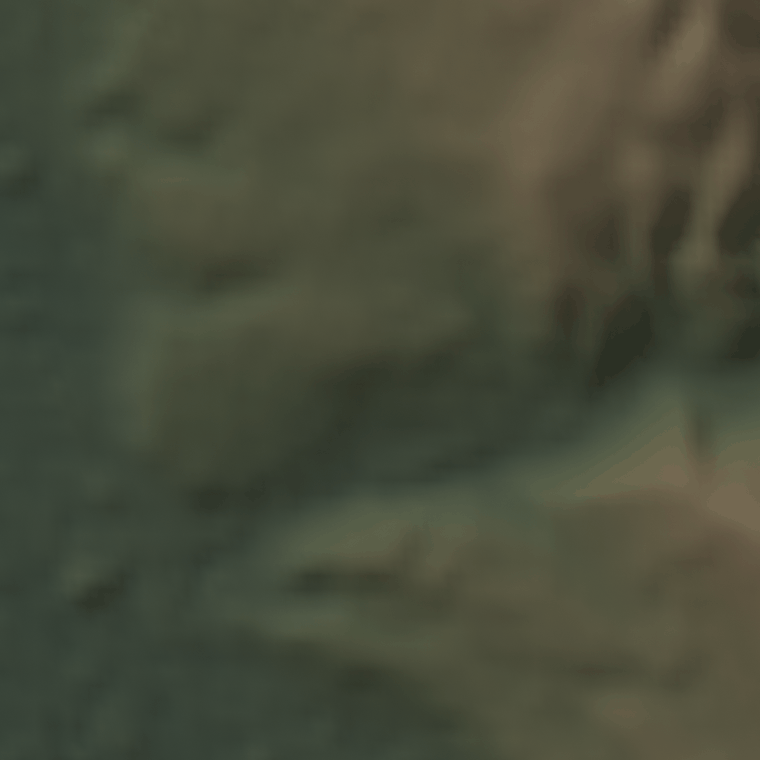

ground only                   std   p5-95 spread
a_flat                       2.01            5.7
b_hillshade                  7.07           24.6
c_hypsometric               10.73           33.9
[PASS] both mechanisms are needed — the flat matte carries 5.7 gray levels of spread across 297 m of relief, the low sun 24.6, and the two together 33.9


bpy.data.materials['SGNB_Hypsometric_DEM_Terrain']

In [20]:
mechanisms = {}
for tag, kw, tint in (
        ("a_flat", dict(look='terrain'), False),
        ("b_hillshade", dict(look='relief'), False),
        ("c_hypsometric", dict(look='relief'), True)):
    if tint:
        sg.context.hypsometric(surface, verbose=False)
    else:
        sg.context.style_context([surface], kind="terrain", shade_smooth=True,
                                 keep_imagery=False)
    frame = dict(FIGURE)
    frame.update(kw)
    bare = nb.render(net, f"renders/07_terrain/3_relief_{tag}",
                     hide=[net], **frame)
    mechanisms[tag] = sg.render.relief_contrast(bare)
    nb.show(bare, width=430)

print(f"{'ground only':<26} {'std':>6} {'p5-95 spread':>14}")
for tag, result in mechanisms.items():
    print(f"{tag:<26} {result['std']:>6.2f} {result['spread']:>14.1f}")

check("both mechanisms are needed",
      mechanisms["c_hypsometric"]["spread"] > mechanisms["b_hillshade"]["spread"]
      > mechanisms["a_flat"]["spread"],
      f"the flat matte carries {mechanisms['a_flat']['spread']:.1f} gray "
      f"levels of spread across "
      f"{surface.get('dem_elev_max') - surface.get('dem_elev_min'):.0f} m "
      f"of relief, the low sun {mechanisms['b_hillshade']['spread']:.1f}, "
      f"and the two together {mechanisms['c_hypsometric']['spread']:.1f}")

# The rest of the composites expect the tint.
sg.context.hypsometric(surface, verbose=False)

## 9 · Edge grades

`bpy.ops.scigraphs.osmnx_add_edge_grades()` computes, for every edge, the
rise between its endpoints over its length, and writes `grade` and
`grade_abs` onto the graph and onto the mesh as `edge_grade` and
`edge_grade_abs`. It needs elevations on the nodes, which is why its `poll`
refuses until section 6 has run.

In [21]:
sg.graphs.activate(net)
print("osmnx_add_edge_grades ->", bpy.ops.scigraphs.osmnx_add_edge_grades())

print(f"mean |grade|  {net.get('osmnx_grade_mean_abs') * 100:>5.1f} %")
print(f"max  |grade|  {net.get('osmnx_grade_max_abs') * 100:>5.1f} %")
print(f"edges over 5% {net.get('osmnx_steep_pct'):>5.1f} %")
print("mesh attributes:",
      [a.name for a in net.data.attributes if a.name.startswith("edge_grade")])

check("the mesh carries the grade", "edge_grade_abs" in net.data.attributes)

Edge grades calculated
Info: Grades calculated: 2224 edges. Mean: 8.9%, Max: 188.5%
osmnx_add_edge_grades -> {'FINISHED'}
mean |grade|    8.9 %
max  |grade|  188.5 %
edges over 5%  54.5 %
mesh attributes: ['edge_grade', 'edge_grade_abs']
[PASS] the mesh carries the grade


True

> **Read the maximum before believing it.** The mean above is a
> measurement; the maximum is the sampling. The elevations came from a raster
> holding one value per 30 m, sampled by `georaster.get_elevation_at`, a
> nearest-pixel lookup and not an interpolation, so a short segment whose
> endpoints fall in adjacent cells inherits the whole difference between them
> and divides it by its own length. That gives grades in the tens of percent
> on streets that are merely steep, and occasionally past 100 %, a rise
> longer than the run, on segments of a dozen meters.

Section 3 put a number on the other half: the six datasets disagree by a
couple of meters at the median network vertex and by tens at the worst, so a
single edge's grade is *dataset-dependent* as well as noisy. The mean over a
whole network is stable; the maximum is not.

Colored by absolute grade, on the `paper` look because a grade
map is a map.

The top of the ramp is pinned at 20 % rather than at the maximum: left free,
the sampling artifact above stretches the scale past 100 % and most of the
network collapses into the dark end. Twenty percent is about where a street
stops being an ordinary street, so everything steeper is simply "steep". It
is pinned through `clip_high_pct` and not `vmax`: `color_graph(vmax=...)`
sets `scigraphs_coloring.vmax` and clears `auto_range`, then the operator it
fires, `scigraphs.color_set_attribute`, calls `update_property_range()`,
which overwrites `vmin` and `vmax` with the attribute's raw extremes. The
manual range is discarded silently; `color_range()` reporting the raw maximum
is the only trace. The percentile arguments are read later and survive, so
the ceiling is expressed as the percentile that lands on 20 %.

The tubes are also thickened. `autoscale_geometry` derives the edge radius
from the mean degree, a quarter of the node radius on a street network, which
at 900 px across 1.3 km is under two pixels; a two-pixel tube antialiased
against a light background loses most of its color. So the radius is
overridden and `autosize=False` keeps the render from recomputing it.

20% grade is the 95.9th percentile of the 1388 mesh edges
  Promoted 2 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_grade_abs  ·  edge_grade_abs -> inferno [log]  [0 … 0.1976] on Point


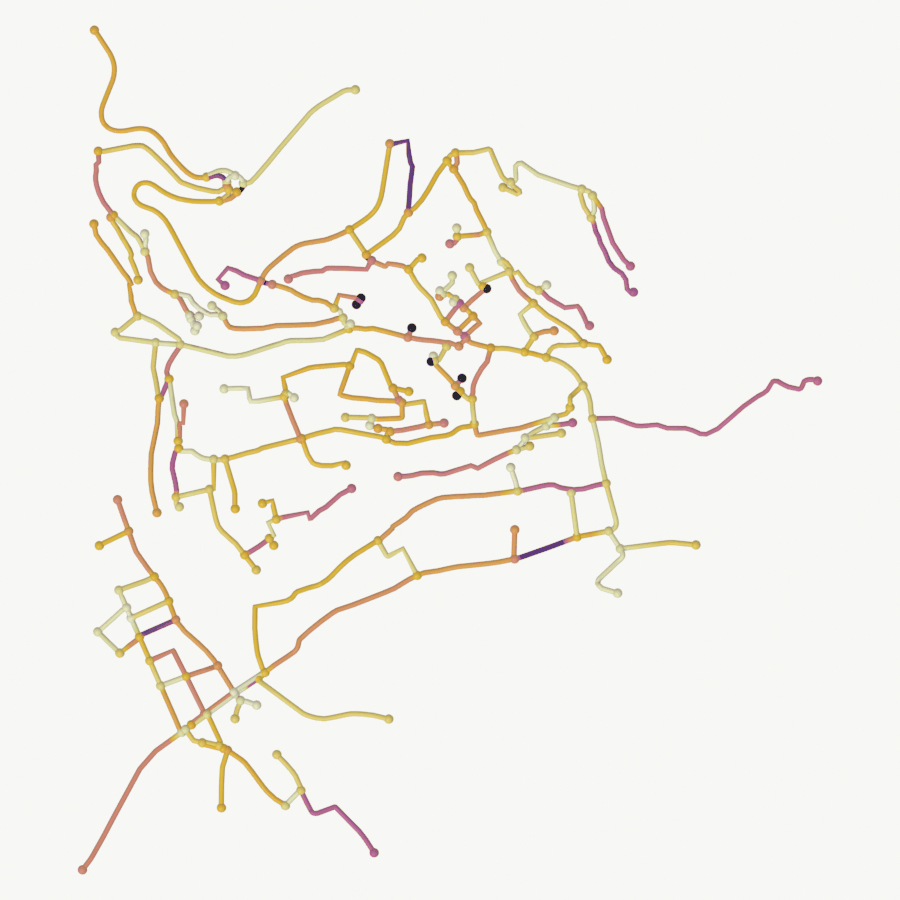

[PASS] 4_edge_grades.png legible — 7.8% ink (healthy range 0.5–60%)
color range in use: (0.0, 0.1976)


In [22]:
GRADE_CEILING = 0.20

values = np.empty(len(net.data.edges), dtype=np.float32)
net.data.attributes["edge_grade_abs"].data.foreach_get("value", values)
ceiling_pct = float((values <= GRADE_CEILING).mean() * 100.0)
print(f"{GRADE_CEILING * 100:.0f}% grade is the "
      f"{ceiling_pct:.1f}th percentile of the {len(values)} mesh edges")

sg.render.autoscale_geometry(net, verbose=False)
net["scigraphs_edge_thickness"] = float(net["scigraphs_node_size"]) * 0.55

nb.figure(net, "renders/07_terrain/4_edge_grades",
          isolate=True, resolution=(900, 900), look='paper',
          autosize=False,
          color_attribute='edge_grade_abs', colormap='inferno',
          clip_high_pct=ceiling_pct)
print("color range in use:", tuple(round(v, 4) for v in sg.render.color_range(net)))

## 10 · What a grade-weighted route is

A shortest path minimizes a sum over edges; change what is summed and
"shortest" means something else. SciGraphs offers three weights on
`osmnx_path_weight`, and the third needs everything above:

```
elevation_impedance  =  length x (1 + alpha x |grade|)
```

`alpha` is `osmnx_impedance_alpha`. At 0 it is distance; at 5 a 10 % slope
costs half as much again as flat ground of the same length. It is a
preference, not a physical model: no claim that climbing is 1.5 times as
tiring, only that the router trades meters for meters of climb at that rate.

How often the weight changes anything is a property of the network rather
than of alpha: a car network up a hill is a handful of graded ramps, often
with no second way round. The sample below counts.

In [23]:
# From `INSTALLED`, as in section 1: the elevations and grades live in the
# installed copy's cache. This tree's `SciGraphs` has an empty one and would
# hand back a graph rebuilt from custom properties, with no elevation at all.
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
routing = importlib.import_module("scigraphs_core.osmnx.routing")

G = graph_cache.get_osmnx_graph(net)
elevations = {n: d.get("elevation") for n, d in G.nodes(data=True)}
print(f"{sum(1 for v in elevations.values() if v is not None)} of "
      f"{G.number_of_nodes()} nodes carry an elevation")

import random

import networkx as nx

reachable = max(nx.weakly_connected_components(G), key=len)
usable = [n for n in reachable if elevations[n] is not None]
print(f"{len(usable)} usable nodes, "
      f"{min(elevations[n] for n in usable):.0f} - "
      f"{max(elevations[n] for n in usable):.0f} m")

# Fixed seed: the sample is a measurement and has to be the same on a re-run.
ALPHA = 5.0
SAMPLE = 80
rng = random.Random(20260812)

comparisons = []
# 160 Dijkstra runs, each logging a line. `nb.quiet()` closes fd 1 for these.
with nb.quiet():
    while len(comparisons) < SAMPLE:
        origin, destination = rng.sample(usable, 2)
        plain = routing.calculate_shortest_path(G, origin, destination,
                                                weight="length")
        if not plain or "path" not in plain:
            continue
        gentle = routing.calculate_shortest_path(
            G, origin, destination, weight="elevation_impedance",
            impedance_alpha=ALPHA)
        if not gentle or "path" not in gentle:
            continue
        comparisons.append((routing.summarize_route(G, plain["path"]),
                           routing.summarize_route(G, gentle["path"]),
                           plain["path"] != gentle["path"], origin, destination))

changed = [c for c in comparisons if c[2]]
print(f"\n{len(comparisons)} origin-destination pairs, "
      f"{len(changed)} took a different route under the grade weight "
      f"({len(changed) / len(comparisons) * 100:.0f} %)")

if changed:
    extra = [(g["length_m"] - p["length_m"]) / p["length_m"] * 100
             for p, g, _d, _o, _t in changed]
    saved = [(p["mean_grade_abs"] - g["mean_grade_abs"]) * 100
             for p, g, _d, _o, _t in changed]
    extra.sort()
    saved.sort()
    print(f"  where it changed: {extra[len(extra) // 2]:+.1f} % of distance "
          f"(median) for {saved[len(saved) // 2]:+.1f} points of mean slope")

check("the grade weight changes some routes and not most of them",
      0 < len(changed) < len(comparisons),
      "a drive network up a hillside is a handful of graded ramps; where "
      "there is no second way round, no weight invents one")

207 of 207 nodes carry an elevation
207 usable nodes, 692 - 826 m
Shortest path: 10 nodes, 437.2m [length]
Shortest path: 10 nodes, 437.2m [_elevation_impedance]
Shortest path: 39 nodes, 3371.7m [length]
Shortest path: 39 nodes, 3371.7m [_elevation_impedance]
Shortest path: 10 nodes, 847.8m [length]
Shortest path: 10 nodes, 847.8m [_elevation_impedance]
Shortest path: 11 nodes, 835.5m [length]
Shortest path: 11 nodes, 835.5m [_elevation_impedance]
Shortest path: 14 nodes, 624.1m [length]
Shortest path: 14 nodes, 624.1m [_elevation_impedance]
Shortest path: 17 nodes, 1723.9m [length]
Shortest path: 17 nodes, 1723.9m [_elevation_impedance]
Shortest path: 9 nodes, 603.1m [length]
Shortest path: 9 nodes, 603.1m [_elevation_impedance]
Shortest path: 11 nodes, 465.8m [length]
Shortest path: 11 nodes, 465.8m [_elevation_impedance]
Shortest path: 26 nodes, 2439.9m [length]
Shortest path: 26 nodes, 2439.9m [_elevation_impedance]
Shortest path: 21 nodes, 1556.4m [length]
Shortest path: 21 nodes,

True

The pair with the most to gain, in full. This is the one the
operators below are pointed at.

In [24]:
best = max(changed, key=lambda c: c[0]["mean_grade_abs"] - c[1]["mean_grade_abs"])
plain_route, gentle_route, _differs, origin, destination = best

print(f"{'weight':<24} {'alpha':>6} {'length':>9} {'mean |grade|':>13} {'rise':>7}")
summaries = {}
for weight, alpha in (("length", 0.0), ("elevation_impedance", ALPHA),
                      ("elevation_impedance", 30.0)):
    with nb.quiet():
        result = routing.calculate_shortest_path(G, origin, destination,
                                                 weight=weight,
                                                 impedance_alpha=alpha)
    summary = routing.summarize_route(G, result["path"])
    summaries[(weight, alpha)] = summary
    print(f"{weight:<24} {alpha:>6.0f} {summary['length_m']:>7.0f} m "
          f"{summary['mean_grade_abs'] * 100:>11.1f} % "
          f"{summary.get('rise_m', float('nan')):>5.0f} m")

check("the grade-weighted route is longer and gentler",
      gentle_route["length_m"] >= plain_route["length_m"]
      and gentle_route["mean_grade_abs"] < plain_route["mean_grade_abs"],
      f"{gentle_route['length_m'] - plain_route['length_m']:+.0f} m of "
      f"distance buys "
      f"{(plain_route['mean_grade_abs'] - gentle_route['mean_grade_abs']) * 100:.1f} "
      "points of mean slope")

weight                    alpha    length  mean |grade|    rise
Shortest path: 14 nodes, 988.4m [length]
length                        0     988 m         7.6 %    24 m
Shortest path: 16 nodes, 1008.7m [_elevation_impedance]
elevation_impedance           5    1009 m         5.5 %    14 m
Shortest path: 16 nodes, 1008.7m [_elevation_impedance]
elevation_impedance          30    1009 m         5.5 %    14 m
[PASS] the grade-weighted route is longer and gentler — +20 m of distance buys 2.1 points of mean slope


True

Raising alpha from 5 to 30 usually moves nothing further. The
weight is a threshold on a discrete set of alternatives, not a dial: once the
gentler of the two available ramps has been chosen, there is no third one to
buy with a larger penalty.

### The same route, through the operators

`bpy.ops.scigraphs.osmnx_k_shortest()` reads `osmnx_path_weight` and
`osmnx_impedance_alpha` off the scene, marks the best path on the mesh as
`on_path` (points) and `on_path_edge` (edges), and stores it as
`osmnx_last_path`. `osmnx_route_summary` writes the aggregates onto the
object; `osmnx_route_elev_profile` turns the path into a Blender curve of
cumulative distance against height.

In [25]:
props.osmnx_shortest_path_source = str(origin)
props.osmnx_shortest_path_target = str(destination)
props.osmnx_k_shortest = 1
props.osmnx_path_weight = 'elevation_impedance'
props.osmnx_impedance_alpha = ALPHA

sg.graphs.activate(net)
print("osmnx_k_shortest ->", bpy.ops.scigraphs.osmnx_k_shortest())
sg.graphs.activate(net)
print("osmnx_route_summary ->", bpy.ops.scigraphs.osmnx_route_summary())
print(f"  {net.get('osmnx_route_length_km'):.3f} km, "
      f"mean |grade| {net.get('osmnx_route_mean_grade_abs') * 100:.1f} %, "
      f"rise {net.get('osmnx_route_rise_m'):.0f} m")

sg.graphs.activate(net)
print("osmnx_route_elev_profile ->", bpy.ops.scigraphs.osmnx_route_elev_profile())
profile = next((o for o in bpy.data.objects if o.type == 'CURVE'
               and "elev_profile" in o.name), None)
if profile is not None:
    print(f"  profile curve: {len(profile.data.splines[0].points)} samples")
    # A diagram, not part of the terrain.
    profile.hide_render = True

check("the route is marked on the mesh", "on_path_edge" in net.data.attributes)

k-shortest paths: found 2 / k=2
Info: Found 2 routes: 1.01km, 1.01km
osmnx_k_shortest -> {'FINISHED'}
Info: Length 1.01km, rise 14m
osmnx_route_summary -> {'FINISHED'}
  1.009 km, mean |grade| 5.5 %, rise 14 m
Info: Elevation profile: 16 samples
osmnx_route_elev_profile -> {'FINISHED'}
  profile curve: 16 samples
[PASS] the route is marked on the mesh


True

The network colored by the route: one edge attribute, two
values.

  Promoted 3 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> on_path_edge  ·  on_path_edge -> cividis [log]  [0 … 1] on Point


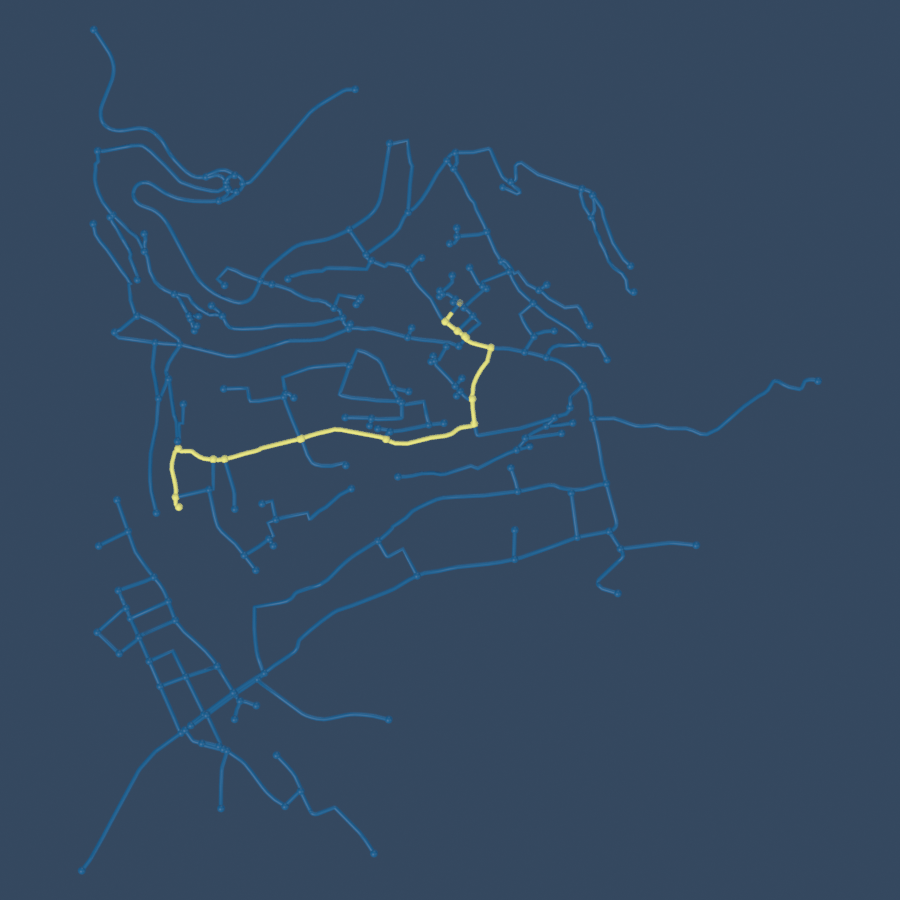

[PASS] 5_route_by_grade.png legible — 6.0% ink (healthy range 0.5–60%)


In [26]:
sg.render.autoscale_geometry(net, node_fraction=0.30, verbose=False)
net["scigraphs_edge_thickness"] = float(net["scigraphs_node_size"]) * 0.55

nb.figure(net, "renders/07_terrain/5_route_by_grade",
          isolate=True, resolution=(900, 900), look='blueprint',
          autosize=False,
          color_attribute='on_path_edge', colormap='cividis')

## 11 · Saving

In [27]:
output_dir = nb.out("11_terrain")
output_dir.mkdir(parents=True, exist_ok=True)

rows = ["dataset,resolution_m,columns,rows,min_m,max_m,relief_m,dtype,"
        "whole_meters_pct,median_diff_vs_chosen_m"]
for name, (_path, raster) in rasters.items():
    values = np.asarray(raster.data, dtype=np.float64)
    finite = values[np.isfinite(values)]
    delta = sampled[name] - sampled[DATASET]
    rows.append(
        f"{name},{DEM_DATASETS[name]['resolution']},{values.shape[1]},"
        f"{values.shape[0]},{np.nanmin(values):.2f},{np.nanmax(values):.2f},"
        f"{np.nanmax(values) - np.nanmin(values):.2f},{raster.data.dtype},"
        f"{np.mean(np.abs(finite - np.round(finite)) < 1e-6) * 100:.1f},"
        f"{np.nanmedian(np.abs(delta)):.2f}")
(output_dir / "dem_datasets.csv").write_text("\n".join(rows) + "\n",
                                             encoding="utf-8")

rows = ["weight,alpha,length_m,mean_grade_abs,rise_m"]
for (weight, alpha), summary in summaries.items():
    rows.append(f"{weight},{alpha:.0f},{summary['length_m']:.1f},"
                f"{summary['mean_grade_abs']:.5f},{summary.get('rise_m', 0):.1f}")
(output_dir / "routes_by_weight.csv").write_text("\n".join(rows) + "\n",
                                                 encoding="utf-8")

print("written to", nb.rel(output_dir))
for entry in sorted(output_dir.iterdir()):
    print("  ", entry.name, f"{entry.stat().st_size / 1e3:.1f} kB")

written to notebooks/out/11_terrain
   dem_datasets.csv 0.2 kB
   routes_by_weight.csv 0.2 kB


## Summary

| Question | Call | Cost |
|---|---|---|
| Is the key readable? | `dem_download.get_api_key()` | none |
| Elevation, this notebook's route | `osmnx_dem_source='OPENTOPOGRAPHY'` | a key, `rasterio`, ~11 s a request |
| Name the dataset | `bpy.ops.scigraphs.download_dem(dataset=...)` | the preference has no override |
| Elevation, offline | `osmnx_dem_source='LOCAL_GEOTIFF'` | `rasterio` |
| Elevation, no key | `osmnx_dem_source='OPEN_ELEVATION'` | see section 1 for what it costs |
| Move the graph onto it | `osmnx_apply_elevation_3d` | plus an offset in meters |
| Slope per edge | `osmnx_add_edge_grades` | needs node elevations |
| Route that avoids climbing | `osmnx_path_weight='elevation_impedance'` | needs grades |
| Exaggerate | `osmnx_elevation_scale`, and the surface by hand | section 7 |
| Check the terrain is under the graph | `sg.context.check_alignment()` | none |
| Make relief readable from above | `look='relief'` + `sg.context.hypsometric()` | section 8 |
| Measure what the network covers | `sg.render.differing_fraction()` | one extra render |

Next: **09 · Imagery**, which puts a photograph on the surface built here.